<a href="https://colab.research.google.com/github/suphitchakh-web/SC663402_Data-Warehouse-and-Big-Data-Analytics/blob/main/Project1_part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# Part 1: Social Listening Warm-up
*งานเดี่ยว — ทุกคนต้องทำและส่งของตนเอง ไม่ต้องนำเสนอ (10 คะแนน)*

## 673020265-5 นางสาวสุพิชชา คำสิงห์

ใช้ข้อมูลโพสต์สาธารณะจาก **Bluesky**  
https://huggingface.co/datasets/alpindale/two-million-bluesky-posts

ใช้เพียง **1–3 ไฟล์** ก็พอ ไม่จำเป็นต้องโหลดทั้ง dataset

ฟิลด์ที่มี เช่น `text`, `created_at`, `author`, `uri`, `has_images`, `reply_to`, `predicted_language`

## ตอบ 4 คำถามหลัก

1. **คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด
2. **ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด
3. **คนพูดถึงอะไร:** หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ
4. **ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้:** สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

> Part 1 เป็น warm-up ไม่ต้องทำ influencer analysis หรือ reply-network เว้นแต่สนใจทำเพิ่มเอง


## Setup และเตรียมข้อมูล

ในส่วนนี้จะกำหนดค่าที่ใช้ในการวิเคราะห์ และโหลดข้อมูลโพสต์จาก Bluesky
โดยใช้ข้อมูลจำนวน 1–3 ไฟล์ตามข้อกำหนดของงาน

In [17]:
# Import libraries
import pandas as pd
import numpy as np
import json
import os
import glob

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("RANDOM_SEED =", RANDOM_SEED)

RANDOM_SEED = 42


### ตรวจสอบไฟล์ข้อมูล

ตรวจสอบตำแหน่งและชื่อไฟล์ JSONL ที่ดาวน์โหลดจาก
`alpindale/two-million-bluesky-posts`

In [18]:
# ดูไฟล์ JSONL ที่มีอยู่ใน /content
jsonl_files = glob.glob("/content/**/*.jsonl", recursive=True)

for f in jsonl_files:
    size_mb = os.path.getsize(f) / (1024 ** 2)
    print(f"{f} | {size_mb:.2f} MB")

/content/posts_20241127_075630.jsonl | 38.08 MB
/content/posts_20241127_082640.jsonl | 38.28 MB


### อ่านข้อมูลจากไฟล์ JSONL

อ่านข้อมูลจากไฟล์ Bluesky จำนวน 2 ไฟล์ และรวมเป็น DataFrame เดียว
เพื่อใช้ในการวิเคราะห์ Part 1

In [19]:
# กำหนด path ของไฟล์
FILE_1 = "/content/posts_20241127_075630.jsonl"
FILE_2 = "/content/posts_20241127_082640.jsonl"

# อ่าน JSONL
df1 = pd.read_json(FILE_1, lines=True)
df2 = pd.read_json(FILE_2, lines=True)

# รวมข้อมูล
df = pd.concat([df1, df2], ignore_index=True)

print("File 1 rows:", len(df1))
print("File 2 rows:", len(df2))
print("Total rows:", len(df))

File 1 rows: 100000
File 2 rows: 100000
Total rows: 200000


### ตรวจสอบโครงสร้างข้อมูล

ตรวจสอบจำนวนแถว จำนวนคอลัมน์ และชื่อฟิลด์ของข้อมูล
พร้อมดูตัวอย่างโพสต์บางส่วน เพื่อเตรียมข้อมูลสำหรับตอบคำถามทั้ง 4 ข้อ

In [20]:
# ตรวจสอบขนาดของ DataFrame
print("Shape:", df.shape)

# ตรวจสอบชื่อ columns
print("\nColumns:")
print(df.columns.tolist())

# แสดงตัวอย่างข้อมูล 5 แถว
print("\nSample data:")
display(df.head())

Shape: (200000, 6)

Columns:
['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to']

Sample data:


,text,created_at,author,uri,has_images,reply_to
0,기사로서의 실력은 타의 추종을 불허하지만 일상생활토크는 영 어색한 둠쪼롱과 적당히 ...,2024-11-27T07:56:28.535Z,did:plc:z3dbv7bbotsaxzdmmlwoypha,at://did:plc:z3dbv7bbotsaxzdmmlwoypha/app.bsky...,False,None
1,Lovely stuff.,2024-11-27T07:56:28.717Z,did:plc:4dn3nlaku6z3ltxzkxglyqdq,at://did:plc:4dn3nlaku6z3ltxzkxglyqdq/app.bsky...,False,at://did:plc:y7vhfdg5iq7qbotunr767enp/app.bsky...
2,눈이 와방 내려서 무거워진 나무에 햇빛이 쨍하게 드니까 예쁘다,2024-11-27T07:56:21.343Z,did:plc:fn4xjeryjchlrtjwippuumxm,at://did:plc:fn4xjeryjchlrtjwippuumxm/app.bsky...,True,None
3,範の字が使用されているあたり3級以上なんだろうけど、時事を扱った問題も出すんだね。,2024-11-27T07:56:28.499Z,did:plc:aaf7jrpncnzlbiqfzkgugowq,at://did:plc:aaf7jrpncnzlbiqfzkgugowq/app.bsky...,False,None
4,WoAH,2024-11-27T07:56:29.868Z,did:plc:l6fvehl7vj44d44aydnds7qr,at://did:plc:l6fvehl7vj44d44aydnds7qr/app.bsky...,False,at://did:plc:54ordrb4cjngwlivuadayono/app.bsky...


## ข้อ 1 คนโพสต์เมื่อไร

วิเคราะห์จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่มีการโพสต์มากที่สุด
โดยใช้ฟิลด์ `created_at` จากข้อมูล Bluesky จำนวน 200,000 โพสต์

### 1.1 ตรวจสอบและแปลงเวลา

In [21]:
# ตรวจสอบข้อมูล created_at
print("Data type before conversion:", df["created_at"].dtype)

# แปลง created_at เป็น datetime
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True)

print("Data type after conversion:", df["created_at"].dtype)
print("Missing created_at:", df["created_at"].isna().sum())

Data type before conversion: object
Data type after conversion: datetime64[ns, UTC]
Missing created_at: 15664


### 1.2 ตรวจสอบข้อมูล `created_at`

ตรวจสอบจำนวนข้อมูลเวลาที่ใช้วิเคราะห์ได้และข้อมูลที่ขาดหาย
โดยจะไม่นำแถวที่ไม่มี `created_at` ไปคำนวณช่วงเวลาและชั่วโมงที่โพสต์มากที่สุด

In [22]:
# ตรวจสอบจำนวนข้อมูลที่มีและไม่มีเวลา
total_posts = len(df)
valid_time = df["created_at"].notna().sum()
missing_time = df["created_at"].isna().sum()

print("Total posts:", total_posts)
print("Posts with valid created_at:", valid_time)
print("Posts with missing created_at:", missing_time)
print("Missing percentage:", round(missing_time / total_posts * 100, 2), "%")

# ดูช่วงเวลาที่มีข้อมูล
print("\nTime range:")
print("Earliest:", df["created_at"].min())
print("Latest:", df["created_at"].max())

Total posts: 200000
Posts with valid created_at: 184336
Posts with missing created_at: 15664
Missing percentage: 7.83 %

Time range:
Earliest: 2009-03-22 12:47:11+00:00
Latest: 2024-11-30 10:50:04.343000+00:00


### 1.3 ชั่วโมงที่มีการโพสต์มากที่สุด

วิเคราะห์จำนวนโพสต์แยกตามชั่วโมงของวัน โดยใช้เฉพาะโพสต์ที่มี `created_at`
เพื่อหาช่วงเวลาที่มีการโพสต์มากที่สุด

In [23]:
# เลือกเฉพาะโพสต์ที่มี created_at
valid_time_df = df[df["created_at"].notna()].copy()

# ดึงชั่วโมงจาก timestamp (UTC)
valid_time_df["hour"] = valid_time_df["created_at"].dt.hour

# นับจำนวนโพสต์ในแต่ละชั่วโมง
hourly_posts = (
    valid_time_df["hour"]
    .value_counts()
    .sort_index()
)

# หาชั่วโมงที่มีโพสต์มากที่สุด
peak_hour = hourly_posts.idxmax()
peak_count = hourly_posts.max()
peak_percentage = peak_count / len(valid_time_df) * 100

print("Peak posting hour (UTC):", f"{peak_hour:02d}:00–{peak_hour:02d}:59")
print("Number of posts:", peak_count)
print("Percentage:", round(peak_percentage, 2), "%")

print("\nPosts by hour:")
display(hourly_posts.to_frame("post_count"))

Peak posting hour (UTC): 08:00–08:59
Number of posts: 167072
Percentage: 90.63 %

Posts by hour:


,post_count
hour,
0,174
1,170
2,126
3,130
4,156
5,302
6,280
7,10671
8,167072


### 1.4 Visualization: จำนวนโพสต์ตามชั่วโมง

แสดงจำนวนโพสต์ในแต่ละชั่วโมงของวัน โดยใช้เฉพาะโพสต์ที่มีข้อมูล `created_at`
เพื่อให้เห็นการกระจายตัวของเวลาโพสต์และชั่วโมงที่มีจำนวนโพสต์สูงที่สุด

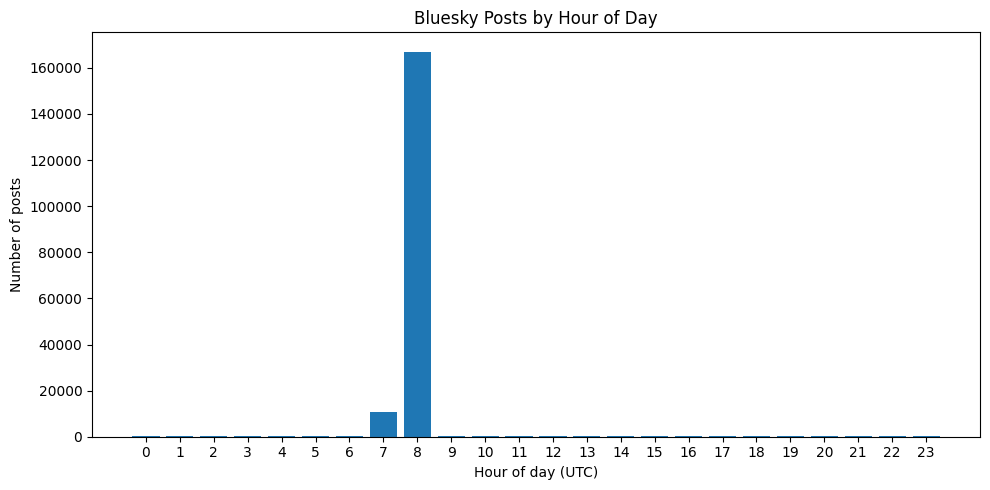

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(hourly_posts.index, hourly_posts.values)

plt.xlabel("Hour of day (UTC)")
plt.ylabel("Number of posts")
plt.title("Bluesky Posts by Hour of Day")

plt.xticks(range(24))
plt.tight_layout()
plt.show()

### 1.5 สรุปผลข้อ 1

จากข้อมูล Bluesky จำนวน 200,000 โพสต์ พบว่าข้อมูลที่นำมาวิเคราะห์ครอบคลุมช่วง
22 มีนาคม 2009 ถึง 30 พฤศจิกายน 2024 (UTC)

มีโพสต์ที่มีข้อมูล `created_at` จำนวน 184,336 โพสต์ หรือ 92.17%
ของข้อมูลทั้งหมด ขณะที่ 15,664 โพสต์ หรือ 7.83% ไม่มีข้อมูลเวลา

เมื่อวิเคราะห์จำนวนโพสต์ตามชั่วโมงของวัน พบว่าช่วง 08:00–08:59 UTC
มีจำนวนโพสต์สูงที่สุด จำนวน 167,072 โพสต์ หรือ 90.63% ของโพสต์ที่มีข้อมูลเวลา

จากกราฟพบว่าจำนวนโพสต์กระจุกตัวอย่างมากในช่วงเวลา 08:00–08:59 UTC
ดังนั้นผลนี้ควรตีความว่าเป็นลักษณะของข้อมูลชุดที่นำมาวิเคราะห์
และไม่ควรสรุปโดยตรงว่าเป็นพฤติกรรมการโพสต์ของผู้ใช้ Bluesky ทั้งหมด
เนื่องจากอาจได้รับอิทธิพลจากวิธีการเก็บหรือคัดเลือกข้อมูลของ dataset

## ข้อ 2 ใช้ภาษาอะไร

เนื่องจากข้อมูลที่เลือกไม่มีฟิลด์ `predicted_language`
จึงใช้ข้อความในฟิลด์ `text` เป็นข้อมูลสำหรับวิเคราะห์ภาษา

ก่อนตรวจภาษา จะตรวจสอบจำนวนข้อความที่มีข้อมูลและลักษณะของข้อความ
เพื่อเตรียมข้อมูลสำหรับการจำแนกภาษา

### 2.1 ตรวจสอบข้อมูลข้อความ

In [25]:
# ตรวจสอบข้อมูล text
total_posts = len(df)

missing_text = df["text"].isna().sum()
empty_text = (df["text"].fillna("").str.strip() == "").sum()

print("Total posts:", total_posts)
print("Missing text:", missing_text)
print("Empty text:", empty_text)

# สร้างชุดข้อมูลข้อความที่ไม่ว่าง
text_df = df[
    df["text"].notna() &
    (df["text"].str.strip() != "")
].copy()

print("Usable text posts:", len(text_df))

# ดูตัวอย่างข้อความ
display(text_df[["text"]].head(10))

Total posts: 200000
Missing text: 0
Empty text: 6021
Usable text posts: 193979


,text
0,기사로서의 실력은 타의 추종을 불허하지만 일상생활토크는 영 어색한 둠쪼롱과 적당히 ...
1,Lovely stuff.
2,눈이 와방 내려서 무거워진 나무에 햇빛이 쨍하게 드니까 예쁘다
3,範の字が使用されているあたり3級以上なんだろうけど、時事を扱った問題も出すんだね。
4,WoAH
5,POV t’es un docteur médiatique et tu vois pass...
6,A weighted blanket made out of little suitcases
7,カース・オブ・労働になってた
8,When is SXSW ?
9,今日あと6時間ある


### 2.2 เตรียมการตรวจสอบภาษา

เนื่องจาก dataset ไม่มีฟิลด์ `predicted_language`
จึงใช้ไลบรารี `langdetect` เพื่อประมาณภาษาจากข้อความใน `text`

การวิเคราะห์จะใช้เฉพาะข้อความที่ไม่ว่าง และกำหนด random seed
เพื่อให้ผลการตรวจสอบสามารถทำซ้ำได้

In [26]:
# ติดตั้ง library สำหรับตรวจภาษา
!pip -q install langdetect

In [27]:
from langdetect import detect, DetectorFactory

# กำหนด seed เพื่อให้ผลตรวจสอบทำซ้ำได้
DetectorFactory.seed = RANDOM_SEED

print("Language detection library: langdetect")
print("Detector seed:", RANDOM_SEED)

Language detection library: langdetect
Detector seed: 42


### 2.3 ทดสอบการตรวจภาษาจากตัวอย่าง

In [28]:
# ทดสอบตรวจภาษาจากข้อความตัวอย่าง 20 โพสต์
sample_texts = text_df["text"].sample(
    n=20,
    random_state=RANDOM_SEED
)

for i, text in enumerate(sample_texts, start=1):
    try:
        language = detect(text)
    except:
        language = "unknown"

    print(f"{i}. [{language}] {text[:150]}")

1. [en] WBBL Knockout time at an absolutely roasting Drummoyne Oval 💚💜
#WBBL10
2. [en] @gtconway.bsky.social Thank you so much for helping to get President Trump reelected.
3. [en] An old cosplay photo from nearly 8 years ago and a reminder of just how damn beautiful the cosplayer formerly known as Scarlet Sparrow is.
4. [unknown] 😭😭😭
5. [pt] 🚨 Oferta 🚨

Monitor LG 24MS500-B, 23.8", Full HD, IPS, 100 Hz, 5 ms (GTG)
R$ 539,10 (R$ 530,10 com o cupom 10VISIONEIRO)
Avaliação: ⭐⭐⭐⭐⭐
Loja: Magazi
6. [en] Attempting to set up an #AfterEffects render farm. Such fun!
7. [ko] 엥?! 지금은 아직 공개 안 된 “SUMMER DAYS” 흘러나오네
8. [en] www.latintimes.com
9. [en] guy I lived with in the early 90s in CO had a couple vhs tapes of Mannix. We would watch that shit late night. Fast forward 30 years and there it is o
10. [en] I'll be the driver then, 🙋🏻‍♀️
11. [unknown] https://longreads.com/2019/05/21/the-fraught-culture-of-online-mourning/
12. [de] #kamenriderfaiz #chaoart The.
13. [da] Random.org 🤣
14. [en] Big th

### 2.4 ตรวจภาษาของโพสต์ทั้งหมด

In [31]:
from tqdm.auto import tqdm

def detect_language(text):
    try:
        return detect(text)
    except:
        return "unknown"

tqdm.pandas(desc="Detecting languages")

# ตรวจภาษาและเก็บผลลง column language
text_df["language"] = text_df["text"].progress_apply(detect_language)

print("Language detection completed.")
print("Columns:", text_df.columns.tolist())
print("Total classified texts:", len(text_df))

Detecting languages:   0%|          | 0/193979 [00:00<?, ?it/s]

Language detection completed.
Columns: ['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to', 'language']
Total classified texts: 193979


In [32]:
# นับจำนวนแต่ละภาษา
language_counts = text_df["language"].value_counts()

# คำนวณสัดส่วน
language_summary = pd.DataFrame({
    "language": language_counts.index,
    "count": language_counts.values
})

language_summary["percentage"] = (
    language_summary["count"] / len(text_df) * 100
)

# แสดงทุกภาษา
display(language_summary)

,language,count,percentage
0,en,95393,49.176973
1,ja,27110,13.975740
2,es,9875,5.090757
3,de,8920,4.598436
4,ko,7372,3.800411
5,fr,6606,3.405523
6,unknown,5312,2.738441
7,pt,3080,1.587801
8,nl,2929,1.509957
9,it,2415,1.244980


In [30]:
print(text_df.columns.tolist())

['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to']


In [33]:
# แสดง 10 ภาษาที่พบมากที่สุด
top_languages = language_summary.head(10).copy()

display(top_languages)

,language,count,percentage
0,en,95393,49.176973
1,ja,27110,13.975740
2,es,9875,5.090757
3,de,8920,4.598436
4,ko,7372,3.800411
5,fr,6606,3.405523
6,unknown,5312,2.738441
7,pt,3080,1.587801
8,nl,2929,1.509957
9,it,2415,1.244980


### 2.5 จำนวนและสัดส่วนของแต่ละภาษา

นับจำนวนโพสต์ในแต่ละภาษาจากข้อความที่สามารถตรวจภาษาได้
และคำนวณสัดส่วนเทียบกับโพสต์ที่มีข้อความที่ไม่ว่างทั้งหมด

In [34]:
# นับจำนวนโพสต์ในแต่ละภาษา
language_counts = text_df["language"].value_counts()

# สร้างตารางสรุป
language_summary = pd.DataFrame({
    "language": language_counts.index,
    "count": language_counts.values
})

# คำนวณสัดส่วน
language_summary["percentage"] = (
    language_summary["count"] / len(text_df) * 100
)

# แสดง 15 ภาษาที่พบมากที่สุด
top_languages = language_summary.head(15).copy()

display(top_languages)

,language,count,percentage
0,en,95393,49.176973
1,ja,27110,13.975740
2,es,9875,5.090757
3,de,8920,4.598436
4,ko,7372,3.800411
5,fr,6606,3.405523
6,unknown,5312,2.738441
7,pt,3080,1.587801
8,nl,2929,1.509957
9,it,2415,1.244980


### 2.6 Visualization: ภาษาที่พบมากที่สุด

แสดงจำนวนโพสต์ของภาษาที่พบมากที่สุด เพื่อเปรียบเทียบการกระจายของภาษา
ในข้อมูล Bluesky ที่นำมาวิเคราะห์

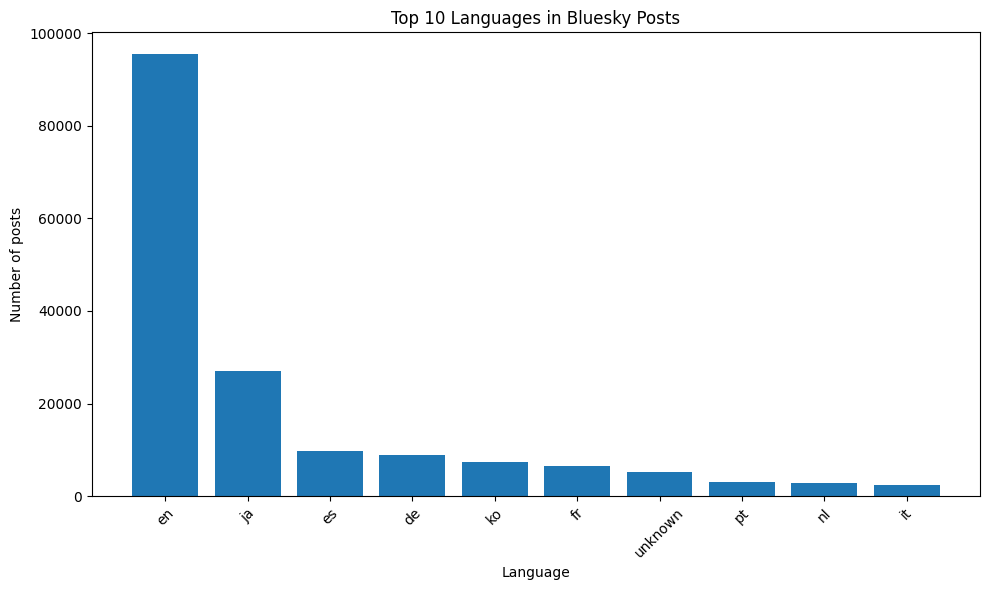

In [35]:
import matplotlib.pyplot as plt

# ใช้ 10 ภาษาที่พบมากที่สุด
plot_data = language_summary.head(10).copy()

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["language"],
    plot_data["count"]
)

plt.xlabel("Language")
plt.ylabel("Number of posts")
plt.title("Top 10 Languages in Bluesky Posts")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
# สรุปสัดส่วนภาษาเฉพาะข้อความที่ตรวจภาษาได้
classified_language_summary = (
    text_df.loc[text_df["language"] != "unknown", "language"]
    .value_counts()
    .rename_axis("language")
    .reset_index(name="count")
)

classified_total = classified_language_summary["count"].sum()

classified_language_summary["percentage"] = (
    classified_language_summary["count"] / classified_total * 100
)

display(classified_language_summary.head(15))


,language,count,percentage
0,en,95393,50.561571
1,ja,27110,14.369233
2,es,9875,5.234090
3,de,8920,4.727907
4,ko,7372,3.907414
5,fr,6606,3.501407
6,pt,3080,1.632506
7,nl,2929,1.552471
8,it,2415,1.280033
9,tr,2080,1.102472


### 2.7 ตรวจสอบข้อความที่ไม่สามารถระบุภาษาได้

ตรวจสอบจำนวนและสัดส่วนของข้อความที่ระบบไม่สามารถระบุภาษาได้
เพื่อไม่ให้ตีความ `unknown` เป็นภาษาหนึ่งในการสรุปผล

In [36]:
unknown_count = (text_df["language"] == "unknown").sum()
classified_count = len(text_df) - unknown_count

print("Total non-empty texts:", len(text_df))
print("Successfully classified:", classified_count)
print("Unknown:", unknown_count)
print(
    "Unknown percentage:",
    round(unknown_count / len(text_df) * 100, 2),
    "%"
)

Total non-empty texts: 193979
Successfully classified: 188667
Unknown: 5312
Unknown percentage: 2.74 %


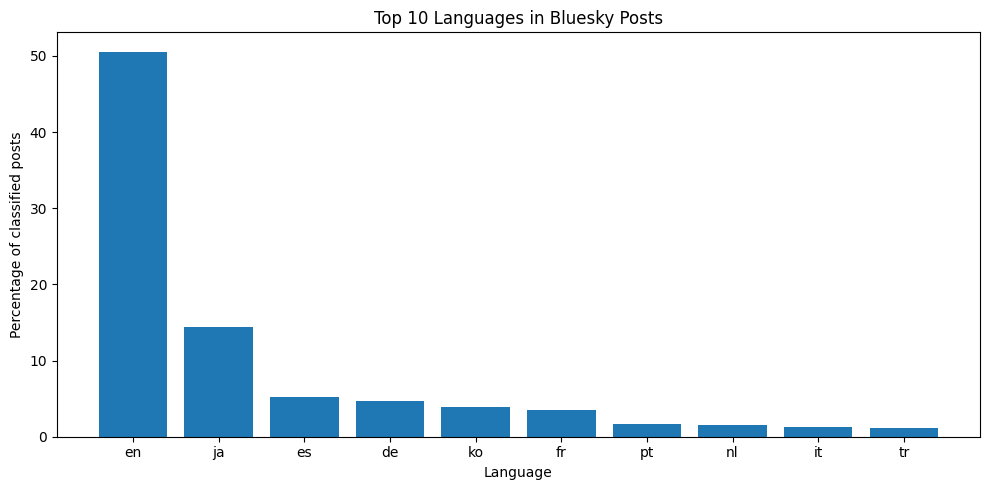

In [38]:
import matplotlib.pyplot as plt

top_lang = classified_language_summary.head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_lang["language"], top_lang["percentage"])
plt.xlabel("Language")
plt.ylabel("Percentage of classified posts")
plt.title("Top 10 Languages in Bluesky Posts")
plt.tight_layout()
plt.show()

### 2.8 บันทึกผลการตรวจภาษาไว้ก่อน

จากโพสต์ที่มีข้อความไม่ว่างจำนวน 193,979 โพสต์
ระบบสามารถตรวจจำแนกภาษาได้ 188,667 โพสต์ หรือ 97.26%
ส่วนอีก 5,312 โพสต์ หรือ 2.74% ไม่สามารถระบุภาษาได้ (`unknown`)

ภาษาที่พบมากที่สุดคือ [ภาษา] จำนวน [จำนวน] โพสต์
คิดเป็น [เปอร์เซ็นต์]% ของโพสต์ที่นำมาตรวจภาษา
รองลงมาคือ [ภาษา] และ [ภาษา]

ดังนั้น ข้อมูลชุดนี้แสดงให้เห็นว่าภาษา [ภาษา]
เป็นภาษาที่พบมากที่สุดในโพสต์ตัวอย่างที่นำมาวิเคราะห์
อย่างไรก็ตาม ผลนี้สะท้อนเฉพาะข้อมูล 200,000 โพสต์ที่เลือกมา
ไม่ควรตีความว่าเป็นสัดส่วนภาษาของผู้ใช้ Bluesky ทั้งหมด

In [39]:
text_df.to_csv("/content/part1_language_results.csv", index=False)

print("Saved:", "/content/part1_language_results.csv")
print("Rows saved:", len(text_df))

Saved: /content/part1_language_results.csv
Rows saved: 193979


### 2.9 สรุปผลข้อ 2

จากข้อความที่ไม่ว่างจำนวน 193,979 โพสต์ สามารถตรวจจับภาษาได้ 188,667 โพสต์
หรือ 97.26% ส่วนอีก 5,312 โพสต์ หรือ 2.74% ไม่สามารถระบุภาษาได้
จากวิธีการตรวจจับที่ใช้

ภาษาที่พบมากที่สุดคือภาษาอังกฤษ (en) จำนวน 95,393 โพสต์
รองลงมาคือภาษาญี่ปุ่น (ja) จำนวน 27,110 โพสต์ และภาษาสเปน (es)
จำนวน 9,875 โพสต์

ผลดังกล่าวแสดงให้เห็นว่าใน sample ของ dataset นี้ ภาษาอังกฤษเป็นภาษาที่พบมากที่สุด
ขณะที่ภาษาญี่ปุ่น สเปน เยอรมัน เกาหลี และฝรั่งเศสก็มีสัดส่วนที่เห็นได้ชัด
ดังนั้น หากพิจารณาเฉพาะข้อมูลชุดนี้ การรองรับภาษาอังกฤษเป็นประเด็นสำคัญ
และควรพิจารณาภาษาอื่นที่พบในสัดส่วนสูงร่วมด้วย

อย่างไรก็ตาม ผลการตรวจภาษาเป็นการประมาณจากข้อความด้วย `langdetect`
จึงอาจมีความคลาดเคลื่อน โดยเฉพาะข้อความสั้น ข้อความที่มีหลายภาษา
หรือข้อความที่ประกอบด้วย emoji และ URL

## ข้อ 3 คนพูดถึงอะไร

### 3.1 หา Hashtag ที่ถูกใช้บ่อยที่สุด

ในข้อนี้จะวิเคราะห์ hashtag ที่ปรากฏในข้อความของโพสต์
เพื่อดูว่ามีประเด็นหรือหัวข้อใดที่ถูกกล่าวถึงบ่อยในข้อมูลที่นำมาวิเคราะห์
โดยจะนับ hashtag ที่ปรากฏในแต่ละโพสต์เพียงครั้งเดียว
เพื่อไม่ให้การเขียน hashtag ซ้ำในโพสต์เดียวกันทำให้จำนวนสูงเกินจริง

In [40]:
import re
from collections import Counter

# รูปแบบสำหรับค้นหา hashtag
hashtag_pattern = re.compile(r'(?<!\w)#([A-Za-z0-9_]+)')

# หา hashtag ในแต่ละโพสต์
post_hashtags = text_df["text"].str.findall(hashtag_pattern)

# นับ hashtag โดยให้ 1 hashtag ใน 1 โพสต์นับเพียงครั้งเดียว
hashtag_counts = Counter(
    tag.lower()
    for tags in post_hashtags
    for tag in set(tags)
)

# สร้างตาราง Top 20
hashtag_df = pd.DataFrame(
    hashtag_counts.most_common(20),
    columns=["hashtag", "count"]
)

hashtag_df["percentage"] = (
    hashtag_df["count"] / len(text_df) * 100
)

display(hashtag_df)

,hashtag,count,percentage
0,art,517,0.266524
1,nsfw,343,0.176823
2,innovation,305,0.157234
3,booksky,242,0.124756
4,photography,227,0.117023
5,ai,227,0.117023
6,nowplaying,210,0.108259
7,books,186,0.095887
8,bookchallenge,171,0.088154
9,bluesky,151,0.077843


### 3.2 ตรวจสอบการใช้ Hashtag

ก่อนตีความ hashtag จะตรวจสอบก่อนว่ามีโพสต์จำนวนเท่าใดที่มี hashtag
เพราะ hashtag ที่ติดอันดับสูงไม่ได้หมายความว่าโพสต์ส่วนใหญ่ของ dataset
จะต้องพูดถึงหัวข้อนั้น

In [41]:
posts_with_hashtag = (post_hashtags.str.len() > 0).sum()
total_posts = len(text_df)

print("จำนวนโพสต์ที่มีข้อความ:", total_posts)
print("จำนวนโพสต์ที่มี hashtag:", posts_with_hashtag)
print(
    "สัดส่วนโพสต์ที่มี hashtag:",
    round(posts_with_hashtag / total_posts * 100, 2),
    "%"
)
print("จำนวน hashtag ที่ไม่ซ้ำกัน:", len(hashtag_counts))

จำนวนโพสต์ที่มีข้อความ: 193979
จำนวนโพสต์ที่มี hashtag: 19487
สัดส่วนโพสต์ที่มี hashtag: 10.05 %
จำนวน hashtag ที่ไม่ซ้ำกัน: 21782


### 3.3 ตัวอย่างข้อความจริงจาก Hashtag ที่พบบ่อย

เพื่อให้การวิเคราะห์ไม่ได้พิจารณาเฉพาะจำนวน hashtag
จะยกตัวอย่างข้อความจริงจากโพสต์ที่ใช้ hashtag ที่พบมากที่สุด
เพื่อดูว่า hashtag ดังกล่าวถูกใช้ในบริบทใด

In [42]:
# แสดงตัวอย่างข้อความจริงจาก hashtag 5 อันดับแรก
top_5_hashtags = hashtag_df.head(5)["hashtag"].tolist()

for tag in top_5_hashtags:
    print("\n" + "=" * 80)
    print(f"ตัวอย่างโพสต์สำหรับ #{tag}")
    print("=" * 80)

    pattern = rf"(?i)(?<!\w)#{re.escape(tag)}(?!\w)"

    examples = text_df[
        text_df["text"].str.contains(
            pattern,
            regex=True,
            na=False
        )
    ][["text"]].head(3)

    display(examples)


ตัวอย่างโพสต์สำหรับ #art


,text
73,#prsk_FA #鏡音レン \n#kagaminelen #vocaloid #art
466,Still chipping away at this one 😇\n\n#wip #cha...
591,「莉冬」-Chihuyu\n#イラストレーション #イラストレーター #イラスト #田宮彩 ...



ตัวอย่างโพสต์สำหรับ #nsfw


,text
144,#ebony #black #porn #nsfw #lesbian #sapphic
500,first post and it’s a nut vid\n#gay #nsfw #gay...
965,#BNWO #BBC #blm #wld #snowbunny #interracial #...



ตัวอย่างโพสต์สำหรับ #innovation


,text
15018,"In the AI race, slow and steady may just win t..."
18533,The rise of the corporate #innovation unit — h...
18922,"Blog - Le 17ème GA, acteur central d'une Lutte..."



ตัวอย่างโพสต์สำหรับ #booksky


,text
480,Choose 20 books that have stayed with you or i...
920,Choose 20 books that have stayed with you or i...
2812,Choose 20 books that have stayed with you or i...



ตัวอย่างโพสต์สำหรับ #photography


,text
382,Margaret River - Western Australia\n#photograp...
676,Lamps in the cafe. #Photography
2054,The west staircase at The Glasshouse internati...


### 3.4 Visualization: Hashtag ที่พบบ่อยที่สุด

กราฟด้านล่างแสดง hashtag 10 อันดับแรกตามจำนวนโพสต์
เพื่อเปรียบเทียบว่าหัวข้อหรือคำที่ใช้เป็น hashtag ใดปรากฏบ่อยกว่าในข้อมูล

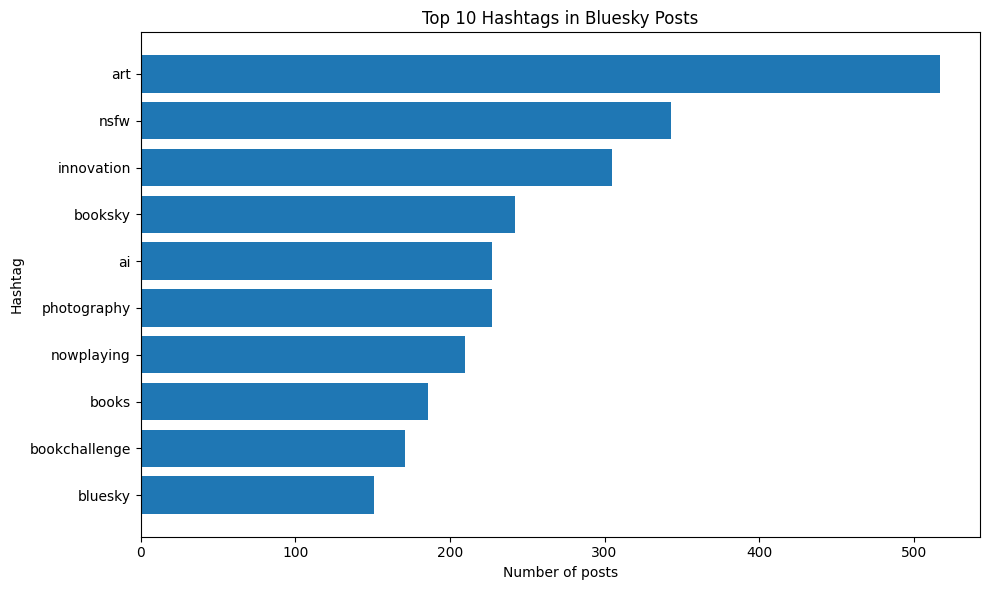

In [43]:
top_10_hashtags = hashtag_df.head(10).sort_values("count")

plt.figure(figsize=(10, 6))
plt.barh(
    top_10_hashtags["hashtag"],
    top_10_hashtags["count"]
)

plt.xlabel("Number of posts")
plt.ylabel("Hashtag")
plt.title("Top 10 Hashtags in Bluesky Posts")
plt.tight_layout()
plt.show()

### 3.5 สรุปผลข้อ 3

จากโพสต์ที่มีข้อความทั้งหมด 193,979 โพสต์ พบว่ามี 19,487 โพสต์
หรือประมาณ 10.05% ที่มีการใช้ hashtag และพบ hashtag ที่ไม่ซ้ำกัน
ทั้งหมด 21,782 รูปแบบ

Hashtag ที่พบในกลุ่มตัวอย่างสะท้อนหัวข้อที่หลากหลาย เช่น `#art`,
`#nsfw`, `#innovation`, `#booksky` และ `#photography`

จากตัวอย่างข้อความจริง พบว่า `#art` มักปรากฏร่วมกับเนื้อหาเกี่ยวกับ
งานศิลปะและการวาดภาพ เช่น โพสต์ที่ใช้ `#kagaminelen`, `#vocaloid`
และ `#illustration` ร่วมกัน ขณะที่ `#innovation` พบในข้อความที่กล่าวถึง
นวัตกรรมและหัวข้อด้านธุรกิจหรือเทคโนโลยี

นอกจากนี้ `#booksky` ปรากฏในโพสต์ที่เกี่ยวข้องกับหนังสือและการแนะนำหนังสือ
ส่วน `#photography` พบในโพสต์ที่บรรยายภาพหรือสถานที่ที่ถ่ายภาพ เช่น
ภาพใน Western Australia และภาพภายในคาเฟ่

ผลการวิเคราะห์นี้แสดงให้เห็นว่าข้อมูลมีหัวข้อที่หลากหลายและมีการใช้ hashtag
ในหลายบริบท อย่างไรก็ตาม มีเพียง 10.05% ของโพสต์ที่มีข้อความทั้งหมดที่ใช้
hashtag ดังนั้น hashtag จึงเป็นเพียงหนึ่งส่วนของข้อมูล และไม่สามารถใช้แทน
หัวข้อของโพสต์ทั้งหมดได้

## ข้อ 4 ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้

### 4.1 Visualization: ภาษาที่พบมากที่สุด

กราฟนี้แสดงสัดส่วนของภาษา 10 อันดับแรกที่ตรวจพบในโพสต์
โดยใช้เฉพาะโพสต์ที่สามารถตรวจจับภาษาได้ เพื่อให้เห็นองค์ประกอบ
ด้านภาษาของข้อมูลที่นำมาวิเคราะห์

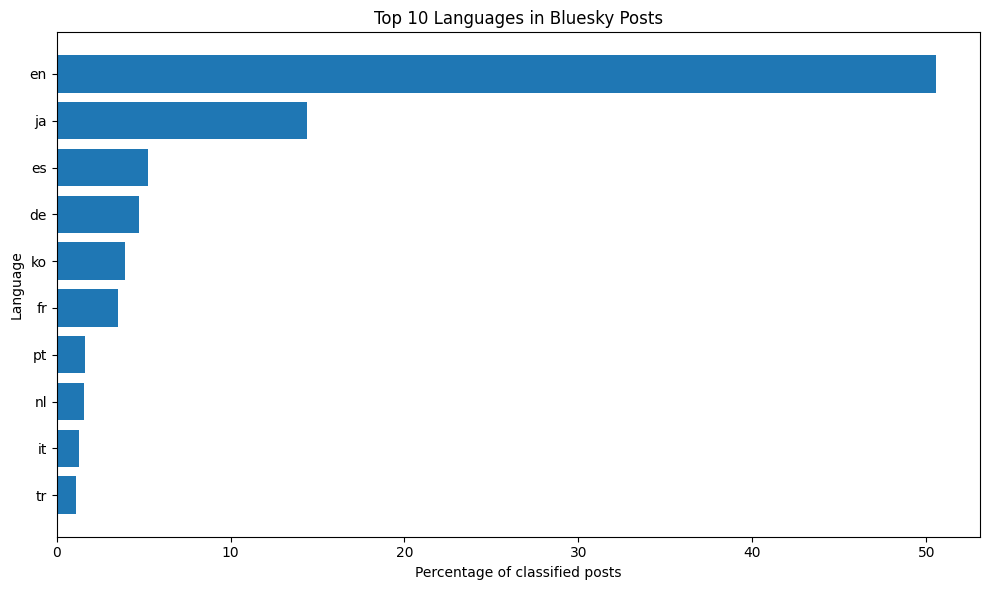

In [44]:
top_10_languages = classified_language_summary.head(10).sort_values("percentage")

plt.figure(figsize=(10, 6))
plt.barh(
    top_10_languages["language"],
    top_10_languages["percentage"]
)

plt.xlabel("Percentage of classified posts")
plt.ylabel("Language")
plt.title("Top 10 Languages in Bluesky Posts")
plt.tight_layout()
plt.show()

### 4.2 ข้อมูลนี้บอกอะไรได้

จากข้อมูล 200,000 โพสต์ที่นำมาวิเคราะห์ สามารถเห็นรูปแบบเบื้องต้นของ
ช่วงเวลาการโพสต์ ภาษา และหัวข้อที่ปรากฏในข้อมูลได้

ด้านเวลา พบว่าโพสต์ที่มีข้อมูลเวลา 184,336 โพสต์ และช่วง 08:00–08:59 UTC
มีจำนวนสูงที่สุดถึง 167,072 โพสต์ หรือ 90.63% ของโพสต์ที่มีข้อมูลเวลา

ด้านภาษา จากข้อความที่ไม่ว่าง 193,979 โพสต์ สามารถตรวจจับภาษาได้
188,667 โพสต์ โดยภาษาอังกฤษเป็นภาษาที่พบมากที่สุด จำนวน 95,393 โพสต์

ด้านหัวข้อ พบว่ามี 19,487 โพสต์ หรือ 10.05% ที่ใช้ hashtag
และพบ hashtag ที่ไม่ซ้ำกัน 21,782 รูปแบบ แสดงให้เห็นว่าข้อมูลมีหัวข้อ
และบริบทที่หลากหลาย

### 4.3 ข้อมูลนี้บอกอะไรไม่ได้

1. ข้อมูลนี้ไม่สามารถใช้สรุปพฤติกรรมของผู้ใช้ Bluesky ทั้งหมดได้
   เพราะเป็นเพียง sample จำนวน 200,000 โพสต์จาก dataset ที่เลือกมาวิเคราะห์

2. การที่โพสต์จำนวนมากกระจุกตัวอยู่ในช่วง 08:00–08:59 UTC
   ไม่สามารถสรุปได้โดยตรงว่าเป็นช่วงเวลาที่ผู้ใช้ Bluesky ทั้งหมดโพสต์มากที่สุด
   เพราะอาจเกี่ยวข้องกับวิธีการเก็บหรือคัดเลือกข้อมูลของ dataset

3. ผลการตรวจจับภาษาเป็นการประมาณจากข้อความด้วย `langdetect`
   จึงอาจมีความคลาดเคลื่อน โดยเฉพาะข้อความสั้น ข้อความหลายภาษา
   หรือข้อความที่มีเพียง emoji และ URL

4. Hashtag พบในเพียง 10.05% ของโพสต์ที่มีข้อความ ดังนั้น hashtag
   ไม่สามารถใช้แทนหัวข้อหรือความสนใจของโพสต์ทั้งหมดได้

5. ข้อมูลนี้ไม่เพียงพอที่จะสรุปเหตุผล ความคิดเห็น หรือความสนใจของผู้ใช้
   เพราะการวิเคราะห์ครั้งนี้เน้นจำนวนและรูปแบบที่ปรากฏในข้อมูล
   ไม่ได้วิเคราะห์บริบทของผู้ใช้แต่ละคนอย่างละเอียด

### 4.4 สรุปภาพรวม Part 1

จากการวิเคราะห์ Bluesky จำนวน 200,000 โพสต์ พบว่าข้อมูลมีรูปแบบที่น่าสนใจ
ทั้งด้านเวลา ภาษา และหัวข้อที่ถูกกล่าวถึง โดยข้อมูลเวลาที่ตรวจสอบได้มี
การกระจุกตัวอย่างมากในช่วง 08:00–08:59 UTC ขณะที่ภาษาอังกฤษเป็นภาษา
ที่พบมากที่สุดในกลุ่มข้อความที่สามารถตรวจจับภาษาได้

ด้านหัวข้อ พบการใช้ hashtag ที่หลากหลาย แต่มีเพียง 10.05% ของโพสต์
ที่มีข้อความที่ใช้ hashtag ดังนั้นผลการวิเคราะห์ควรใช้เพื่อทำความเข้าใจ
ลักษณะของ sample นี้เป็นหลัก ไม่ควรนำไปสรุปแทนผู้ใช้ Bluesky ทั้งหมด

ข้อจำกัดสำคัญอีกประการคือข้อมูลบางส่วนขาดค่า `created_at` และบางข้อความ
ไม่สามารถตรวจจับภาษาได้ จึงต้องระมัดระวังในการตีความผลลัพธ์